In [1]:
# ============================================================
# NOVABUILD SETUP CELL — RUN THIS FIRST IN EVERY SESSION
# ============================================================
import subprocess, time, psycopg2

subprocess.run('apt-get -qq install -y postgresql > /dev/null 2>&1', shell=True)
subprocess.run('service postgresql start > /dev/null 2>&1', shell=True)
time.sleep(3)
subprocess.run("""su postgres -c "psql -c \\"CREATE USER saas_user WITH PASSWORD 'saas_pass';\\" " """, shell=True, capture_output=True)
subprocess.run("""su postgres -c "psql -c \\"CREATE DATABASE novabuilds OWNER saas_user;\\" " """, shell=True, capture_output=True)
subprocess.run("""su postgres -c "psql -c \\"GRANT ALL PRIVILEGES ON DATABASE novabuilds TO saas_user;\\" " """, shell=True, capture_output=True)
exec(open('/content/novabuilds_colab_setup_v2.py').read())
conn = psycopg2.connect(host='localhost', port=5432, dbname='novabuilds', user='saas_user', password='saas_pass')
print("NovaBuild ready. Tables loaded.")
# ============================================================

Connected. Ready.
All 21 tables created.
Loading data...
  ✓ carriers                           15 rows
  ✓ brokers                            40 rows
  ✓ sponsors                           80 rows
  ✓ contractors                      1500 rows
  ✓ projects                          200 rows
  ✓ wrap_programs                     200 rows
  ✓ contractor_enrollments           6000 rows
  ✓ payroll_reports                 18000 rows
  ✓ policies                          600 rows
  ✓ policy_coverages                 1794 rows
  ✓ endorsements                      900 rows
  ✓ premiums                         4500 rows
  ✓ certificates                     9000 rows
  ✓ coi_verifications                9000 rows
  ✓ compliance_tracking              6000 rows
  ✓ prequalifications                1500 rows
  ✓ safety_incidents                 4000 rows
  ✓ inspections                      5000 rows
  ✓ claims                           2500 rows
  ✓ claim_assessments                2500 rows
  ✓

<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


  carriers                           15
  brokers                            40
  sponsors                           80
  contractors                     1,500
  projects                          200
  wrap_programs                     200
  contractor_enrollments          6,000
  payroll_reports                18,000
  policies                          600
  policy_coverages                1,794
  endorsements                      900
  premiums                        4,500
  certificates                    9,000
  coi_verifications               9,000
  compliance_tracking             6,000
  prequalifications               1,500
  safety_incidents                4,000
  inspections                     5,000
  claims                          2,500
  claim_assessments               2,500
  claim_payments                  3,200
----------------------------------------
  TOTAL                          76,529

── COI Compliance Rate by Contractor Tier ──


,tier,total_verifications,compliant,compliance_rate_pct
0,Conditional,2308,1442,62.5
1,Probationary,2437,1513,62.1
2,Preferred,2135,1311,61.4
3,Standard,2120,1285,60.6



── Loss Ratio by Project Type ──


...

,project_type,claim_count,premium_collected_m,incurred_loss_m,loss_ratio_pct
0,School,178,810.84,1155.64,142.5
1,Highway,230,1092.16,1460.01,133.7
2,Data Center,280,1484.33,1919.58,129.3
3,Industrial Facility,264,1132.17,1434.62,126.7
4,Hospital,276,1257.97,1500.13,119.2
5,Bridge,253,1290.77,1428.42,110.7
6,Residential Tower,219,1140.07,1244.48,109.2
7,Commercial Office,289,1329.93,1435.31,107.9
8,Mixed-Use,244,1184.19,1259.70,106.4
9,Retail Complex,267,1445.01,1450.43,100.4



── Contractors with COIs Expiring in 30 Days ──


<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


,company_name,trade,certificate_number,expiration_date,days_until_expiry,last_verification_result



Dataset ready. All queries working.
NovaBuild ready. Tables loaded.


In [ ]:
import psycopg2

conn = psycopg2.connect(
    host='localhost', port=5432,
    dbname='novabuilds',
    user='saas_user', password='saas_pass'
)
cur = conn.cursor()

tables = ['contractors','claims','projects','wrap_programs','policies',
          'premiums','certificates','coi_verifications','safety_incidents',
          'inspections','payroll_reports','claim_assessments','claim_payments',
          'brokers','carriers','sponsors','contractor_enrollments',
          'compliance_tracking','prequalifications','endorsements','policy_coverages']

for t in tables:
    cur.execute(f"SELECT COUNT(*) FROM {t}")
    print(f"{t}: {cur.fetchone()[0]}")

contractors: 1500
claims: 2500
projects: 200
wrap_programs: 200
policies: 600
premiums: 4500
certificates: 9000
coi_verifications: 9000
safety_incidents: 4000
inspections: 5000
payroll_reports: 18000
claim_assessments: 2500
claim_payments: 3200
brokers: 40
carriers: 15
sponsors: 80
contractor_enrollments: 6000
compliance_tracking: 6000
prequalifications: 1500
endorsements: 900
policy_coverages: 1794


In [ ]:
xml = '''<?xml version="1.0" encoding="UTF-8"?>
<mxGraphModel><root><mxCell id="0"/><mxCell id="1" parent="0"/>

<!-- TITLE LEFT -->
<mxCell id="t1" value="Inmon — 3NF Central EDW (PostgreSQL Source)" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=14;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="20" y="20" width="500" height="30" as="geometry"/></mxCell>

<!-- CONTRACTOR GROUP -->
<mxCell id="g1" value="Contractor Group" style="swimlane;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="20" y="60" width="220" height="200" as="geometry"/></mxCell>
<mxCell id="c1" value="contractors" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;" vertex="1" parent="1"><mxGeometry x="40" y="90" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c2" value="contractor_enrollments" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;" vertex="1" parent="1"><mxGeometry x="40" y="135" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c3" value="prequalifications" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;" vertex="1" parent="1"><mxGeometry x="40" y="180" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c4" value="payroll_reports" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;" vertex="1" parent="1"><mxGeometry x="40" y="225" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="e1" edge="1" source="c1" target="c2" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e2" edge="1" source="c1" target="c3" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e3" edge="1" source="c1" target="c4" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- COMPLIANCE GROUP -->
<mxCell id="g2" value="Compliance Group" style="swimlane;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=11;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="260" y="60" width="220" height="160" as="geometry"/></mxCell>
<mxCell id="c5" value="certificates" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#d5e8d4;strokeColor=#82b366;" vertex="1" parent="1"><mxGeometry x="280" y="90" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c6" value="coi_verifications" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#d5e8d4;strokeColor=#82b366;" vertex="1" parent="1"><mxGeometry x="280" y="135" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c7" value="compliance_tracking" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#d5e8d4;strokeColor=#82b366;" vertex="1" parent="1"><mxGeometry x="280" y="180" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="e4" edge="1" source="c5" target="c6" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e5" edge="1" source="c1" target="c6" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- CLAIMS GROUP -->
<mxCell id="g3" value="Claims Group" style="swimlane;fillColor=#ffe6cc;strokeColor=#d6b656;fontSize=11;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="20" y="280" width="220" height="160" as="geometry"/></mxCell>
<mxCell id="c8" value="claims" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#ffe6cc;strokeColor=#d6b656;" vertex="1" parent="1"><mxGeometry x="40" y="310" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c9" value="claim_assessments" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#ffe6cc;strokeColor=#d6b656;" vertex="1" parent="1"><mxGeometry x="40" y="355" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c10" value="claim_payments" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#ffe6cc;strokeColor=#d6b656;" vertex="1" parent="1"><mxGeometry x="40" y="400" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="e6" edge="1" source="c8" target="c9" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e7" edge="1" source="c8" target="c10" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e8" edge="1" source="c1" target="c8" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- PROGRAM GROUP -->
<mxCell id="g4" value="Program Group" style="swimlane;fillColor=#e1d5e7;strokeColor=#9673a6;fontSize=11;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="260" y="240" width="220" height="200" as="geometry"/></mxCell>
<mxCell id="c11" value="wrap_programs" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#e1d5e7;strokeColor=#9673a6;" vertex="1" parent="1"><mxGeometry x="280" y="270" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c12" value="policies" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#e1d5e7;strokeColor=#9673a6;" vertex="1" parent="1"><mxGeometry x="280" y="315" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c13" value="policy_coverages" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#e1d5e7;strokeColor=#9673a6;" vertex="1" parent="1"><mxGeometry x="280" y="360" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="c14" value="premiums" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#e1d5e7;strokeColor=#9673a6;" vertex="1" parent="1"><mxGeometry x="280" y="405" width="140" height="30" as="geometry"/></mxCell>
<mxCell id="e9" edge="1" source="c11" target="c12" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e10" edge="1" source="c12" target="c13" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="e11" edge="1" source="c12" target="c14" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- REFERENCE GROUP -->
<mxCell id="g5" value="Reference Group" style="swimlane;fillColor=#f8cecc;strokeColor=#b85450;fontSize=11;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="20" y="460" width="460" height="120" as="geometry"/></mxCell>
<mxCell id="c15" value="brokers" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="30" y="490" width="100" height="30" as="geometry"/></mxCell>
<mxCell id="c16" value="carriers" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="145" y="490" width="100" height="30" as="geometry"/></mxCell>
<mxCell id="c17" value="sponsors" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="260" y="490" width="100" height="30" as="geometry"/></mxCell>
<mxCell id="c18" value="projects" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="375" y="490" width="100" height="30" as="geometry"/></mxCell>
<mxCell id="c19" value="safety_incidents" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="30" y="535" width="120" height="30" as="geometry"/></mxCell>
<mxCell id="c20" value="inspections" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="170" y="535" width="100" height="30" as="geometry"/></mxCell>
<mxCell id="c21" value="endorsements" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;" vertex="1" parent="1"><mxGeometry x="290" y="535" width="100" height="30" as="geometry"/></mxCell>

<!-- ==================== KIMBALL SIDE ==================== -->
<!-- TITLE RIGHT -->
<mxCell id="t2" value="Kimball — Galaxy Schema (Presentation Layer)" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=14;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="620" y="20" width="500" height="30" as="geometry"/></mxCell>

<!-- CONFORMED DIMS LEGEND -->
<mxCell id="leg" value="★ Conformed Dimension" style="text;html=1;strokeColor=none;fillColor=#fff2cc;align=left;verticalAlign=middle;rounded=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="55" width="160" height="25" as="geometry"/></mxCell>

<!-- CONFORMED DIMS -->
<mxCell id="d1" value="★ dim_contractor" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#fff2cc;strokeColor=#d6b656;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="740" y="160" width="140" height="36" as="geometry"/></mxCell>
<mxCell id="d2" value="★ dim_date" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#fff2cc;strokeColor=#d6b656;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="740" y="420" width="140" height="36" as="geometry"/></mxCell>
<mxCell id="d3" value="★ dim_project" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#fff2cc;strokeColor=#d6b656;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="900" y="290" width="140" height="36" as="geometry"/></mxCell>

<!-- REGULAR DIMS -->
<mxCell id="d4" value="dim_policy" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="160" width="100" height="36" as="geometry"/></mxCell>
<mxCell id="d5" value="dim_carrier" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="290" width="100" height="36" as="geometry"/></mxCell>
<mxCell id="d6" value="dim_program" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="900" y="160" width="100" height="36" as="geometry"/></mxCell>
<mxCell id="d7" value="dim_certificate" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="900" y="420" width="100" height="36" as="geometry"/></mxCell>
<mxCell id="d8" value="dim_broker" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="420" width="100" height="36" as="geometry"/></mxCell>

<!-- FACT TABLES -->
<mxCell id="f1" value="fact_claim" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;fontStyle=1;fontSize=12;" vertex="1" parent="1"><mxGeometry x="720" y="270" width="120" height="40" as="geometry"/></mxCell>
<mxCell id="f2" value="fact_coi_verification" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="840" y="480" width="140" height="40" as="geometry"/></mxCell>
<mxCell id="f3" value="fact_payroll" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="500" width="120" height="40" as="geometry"/></mxCell>
<mxCell id="f4" value="fact_incident" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="840" y="100" width="120" height="40" as="geometry"/></mxCell>
<mxCell id="f5" value="fact_premium" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#f8cecc;strokeColor=#b85450;fontStyle=1;fontSize=11;" vertex="1" parent="1"><mxGeometry x="620" y="80" width="120" height="40" as="geometry"/></mxCell>

<!-- FACT-DIM EDGES fact_claim -->
<mxCell id="fe1" edge="1" source="f1" target="d1" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe2" edge="1" source="f1" target="d2" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe3" edge="1" source="f1" target="d3" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe4" edge="1" source="f1" target="d4" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe5" edge="1" source="f1" target="d5" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe6" edge="1" source="f1" target="d6" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- fact_coi edges -->
<mxCell id="fe7" edge="1" source="f2" target="d1" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe8" edge="1" source="f2" target="d7" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe9" edge="1" source="f2" target="d2" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- fact_payroll edges -->
<mxCell id="fe10" edge="1" source="f3" target="d1" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe11" edge="1" source="f3" target="d2" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- fact_incident edges -->
<mxCell id="fe12" edge="1" source="f4" target="d1" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe13" edge="1" source="f4" target="d3" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- fact_premium edges -->
<mxCell id="fe14" edge="1" source="f5" target="d4" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe15" edge="1" source="f5" target="d8" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="fe16" edge="1" source="f5" target="d2" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

</root></mxGraphModel>'''

with open('/content/kimball_vs_inmon.drawio', 'w') as f:
    f.write(xml)
print("File saved: /content/kimball_vs_inmon.drawio")
print("Download it from the Files panel on the left sidebar")

File saved: /content/kimball_vs_inmon.drawio
Download it from the Files panel on the left sidebar


In [ ]:
conn.rollback()
cur = conn.cursor()

for table in ['claims', 'contractors', 'projects', 'policies', 'wrap_programs']:
    cur.execute(f"SELECT column_name FROM information_schema.columns WHERE table_name='{table}' ORDER BY ordinal_position")
    print(f"{table}: {[r[0] for r in cur.fetchall()]}")

claims: ['claim_id', 'claim_number', 'policy_id', 'program_id', 'project_id', 'carrier_id', 'loss_date', 'report_date', 'claim_type', 'coverage_line', 'claimant_name', 'claimant_type', 'description', 'reserves', 'incurred_loss', 'status', 'adjuster_name', 'litigation', 'subrogation_potential', 'created_at']
contractors: ['contractor_id', 'company_name', 'trade', 'state', 'license_number', 'contact_name', 'contact_email', 'contact_phone', 'employees_count', 'years_in_business', 'annual_revenue', 'emr', 'tier', 'created_at']
projects: ['project_id', 'project_name', 'project_type', 'sponsor_id', 'broker_id', 'state', 'city', 'start_date', 'projected_end_date', 'actual_end_date', 'total_insured_value', 'contract_value', 'status', 'wrap_type', 'created_at']
policies: ['policy_id', 'policy_number', 'program_id', 'project_id', 'carrier_id', 'broker_id', 'policy_type', 'effective_date', 'expiration_date', 'total_insured_value', 'annual_premium', 'deductible', 'status', 'created_at']
wrap_progr

In [ ]:
cur = conn.cursor()

print("=== INMON STYLE — 3NF Query (4 joins to get contractor + project) ===")
cur.execute("""
    SELECT
        c.company_name,
        c.tier,
        p.project_type,
        cl.claim_type,
        cl.incurred_loss
    FROM claims cl
    JOIN policies pol ON cl.policy_id = pol.policy_id
    JOIN contractors c ON pol.contractor_id = c.contractor_id
    JOIN wrap_programs wp ON cl.program_id = wp.program_id
    JOIN projects p ON wp.project_id = p.project_id
    WHERE c.tier = 'Preferred'
    ORDER BY cl.incurred_loss DESC
    LIMIT 5
""")
rows = cur.fetchall()
print(f"{'Company':<35} {'Tier':<12} {'Project Type':<20} {'Claim Type':<20} {'Loss':>12}")
print("-"*100)
for r in rows:
    print(f"{r[0]:<35} {r[1]:<12} {r[2]:<20} {r[3]:<20} {r[4]:>12,.0f}")

print()
print("=== KIMBALL STYLE — Same result, no explicit JOINs needed ===")
print("In Power BI: set tier slicer = Preferred")
print("DAX: Total Incurred Loss = SUM(fact_claim[incurred_loss])")
print("Power BI traverses dim_contractor -> fact_claim automatically")
print("This is why star schema exists — complexity hidden from the user")
conn.commit()

=== INMON STYLE — 3NF Query (4 joins to get contractor + project) ===


UndefinedColumn: column pol.contractor_id does not exist
LINE 10:     JOIN contractors c ON pol.contractor_id = c.contractor_i...
                                   ^
HINT:  Perhaps you meant to reference the column "c.contractor_id".


In [ ]:
conn.rollback()
cur = conn.cursor()

# Check wrap_programs and contractor_enrollments columns
for table in ['wrap_programs', 'contractor_enrollments']:
    cur.execute(f"SELECT column_name FROM information_schema.columns WHERE table_name='{table}' ORDER BY ordinal_position")
    print(f"{table}: {[r[0] for r in cur.fetchall()]}")

In [2]:
conn.rollback()
cur = conn.cursor()

print("=== INMON STYLE — 3NF Query (4 joins) ===")
cur.execute("""
    SELECT
        c.company_name,
        c.tier,
        p.project_type,
        cl.claim_type,
        cl.incurred_loss
    FROM claims cl
    JOIN wrap_programs wp ON cl.program_id = wp.program_id
    JOIN contractor_enrollments ce ON wp.program_id = ce.program_id
    JOIN contractors c ON ce.contractor_id = c.contractor_id
    JOIN projects p ON wp.project_id = p.project_id
    WHERE c.tier = 'Preferred'
    ORDER BY cl.incurred_loss DESC
    LIMIT 5
""")
rows = cur.fetchall()
print(f"{'Company':<35} {'Tier':<12} {'Project Type':<20} {'Claim Type':<20} {'Loss':>12}")
print("-"*100)
for r in rows:
    print(f"{r[0]:<35} {r[1]:<12} {r[2]:<20} {r[3]:<20} {r[4]:>12,.0f}")

conn.commit()
print()
print("=== KIMBALL STYLE — Same result ===")
print("Power BI: tier slicer = Preferred")
print("DAX: SUM(fact_claim[incurred_loss])")
print("Zero JOINs written — relationships handle it automatically")

=== INMON STYLE — 3NF Query (4 joins) ===
Company                             Tier         Project Type         Claim Type                   Loss
----------------------------------------------------------------------------------------------------
United HVAC Builders Inc            Preferred    Retail Complex       Property Damage         2,297,610
Summit Plumbing Builders Inc        Preferred    Retail Complex       Property Damage         2,297,610
United Plumbing Infrastructure LLC  Preferred    Retail Complex       Property Damage         2,297,610
Premier Excavation Building Services Preferred    Retail Complex       Property Damage         2,297,610
Heritage Demolition Infrastructure LLC Preferred    Retail Complex       Property Damage         2,297,610

=== KIMBALL STYLE — Same result ===
Power BI: tier slicer = Preferred
DAX: SUM(fact_claim[incurred_loss])
Zero JOINs written — relationships handle it automatically


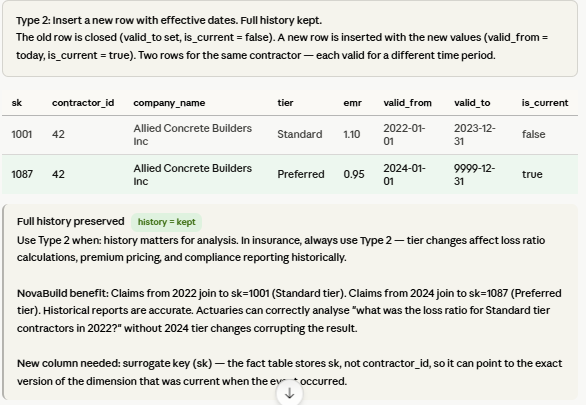

Step 1 — Create the SCD2 table

This is just the contractors table with 4 extra columns added. Run this:

In [3]:
conn.rollback()
cur = conn.cursor()

cur.execute(
    """
    CREATE TABLE IF NOT EXISTS dim_contractor_scd2 AS
    SELECT
      contractor_id,
      company_name,
      trade,
      state,
      tier,
      emr,
      CAST('2020-01-01' AS DATE) AS valid_from,
      CAST('9999-12-31' AS DATE) AS valid_to,
      TRUE AS is_current
    FROM contractors
    """
)
#Add Surrogate Key
cur.execute("ALTER TABLE dim_contractor_scd2 ADD COLUMN sk SERIAL")

conn.commit()
cur.execute("SELECT COUNT(*) FROM dim_contractor_scd2")
print("Rows loaded:", cur.fetchone()[0])

Rows loaded: 1500


In [4]:
cur.execute("""
    SELECT sk, contractor_id, company_name, tier, emr,
           valid_from, valid_to, is_current
    FROM dim_contractor_scd2
    WHERE company_name = 'Allied Concrete Builders Inc'
""")
rows = cur.fetchall()
for r in rows:
    print(f"sk={r[0]} | id={r[1]} | name={r[2]} | tier={r[3]} | emr={r[4]} | valid_from={r[5]} | valid_to={r[6]} | is_current={r[7]}")

sk=127 | id=CON-00127 | name=Allied Concrete Builders Inc | tier=Probationary | emr=1.43 | valid_from=2020-01-01 | valid_to=9999-12-31 | is_current=True


Good. Allied Concrete Builders Inc is currently Probationary tier with EMR 1.43, sk=127.

Step 3 — Simulate the tier change (this is the core SCD Type 2 logic)

In [5]:
# Step 3a: Close the current row
cur.execute("""
    UPDATE dim_contractor_scd2
    SET valid_to = '2024-01-01',
        is_current = FALSE
    WHERE company_name = 'Allied Concrete Builders Inc'
    AND is_current = TRUE
""")

# Step 3b: Insert new row with updated tier
cur.execute("""
    INSERT INTO dim_contractor_scd2
        (contractor_id, company_name, trade, state, tier, emr,
         valid_from, valid_to, is_current)
    SELECT
        contractor_id, company_name, trade, state,
        'Preferred' AS tier,
        0.85 AS emr,
        '2024-01-01' AS valid_from,
        '9999-12-31' AS valid_to,
        TRUE AS is_current
    FROM dim_contractor_scd2
    WHERE company_name = 'Allied Concrete Builders Inc'
    AND is_current = FALSE
    AND valid_to = '2024-01-01'
""")

conn.commit()

# Verify — should now show 2 rows for this contractor
cur.execute("""
    SELECT sk, tier, emr, valid_from, valid_to, is_current
    FROM dim_contractor_scd2
    WHERE company_name = 'Allied Concrete Builders Inc'
    ORDER BY valid_from
""")
rows = cur.fetchall()
print(f"{'sk':<6} {'tier':<14} {'emr':<6} {'valid_from':<14} {'valid_to':<14} {'is_current'}")
print("-"*65)
for r in rows:
    print(f"{r[0]:<6} {r[1]:<14} {r[2]:<6} {str(r[3]):<14} {str(r[4]):<14} {r[5]}")

sk     tier           emr    valid_from     valid_to       is_current
-----------------------------------------------------------------
127    Probationary   1.43   2020-01-01     2024-01-01     False
1501   Preferred      0.85   2024-01-01     9999-12-31     True


In [6]:
conn.rollback()
cur = conn.cursor()

cur.execute("""
    SELECT
        c.company_name,
        c.tier,
        cl.loss_date,
        cl.claim_type,
        cl.incurred_loss
    FROM claims cl
    JOIN wrap_programs wp
        ON cl.program_id = wp.program_id
    JOIN contractor_enrollments ce
        ON ce.program_id = wp.program_id
    JOIN dim_contractor_scd2 c
        ON ce.contractor_id = c.contractor_id
        AND cl.loss_date BETWEEN c.valid_from AND c.valid_to
    WHERE c.company_name = 'Allied Concrete Builders Inc'
    ORDER BY cl.loss_date
    LIMIT 10
""")

rows = cur.fetchall()
print(f"{'Company':<35} {'Tier':<14} {'Loss Date':<14} {'Claim Type':<20} {'Loss':>12}")
print("-"*95)
for r in rows:
    print(f"{r[0]:<35} {r[1]:<14} {str(r[2]):<14} {r[3]:<20} {r[4]:>12,.0f}")

Company                             Tier           Loss Date      Claim Type                   Loss
-----------------------------------------------------------------------------------------------
Allied Concrete Builders Inc        Probationary   2022-02-09     Bodily Injury             808,205
Allied Concrete Builders Inc        Probationary   2022-03-13     Fire/Explosion            788,615
Allied Concrete Builders Inc        Probationary   2022-04-20     Water Damage            1,172,298
Allied Concrete Builders Inc        Probationary   2022-05-16     Property Damage           653,125
Allied Concrete Builders Inc        Probationary   2022-05-18     Third Party Liability      528,743
Allied Concrete Builders Inc        Probationary   2022-07-28     Third Party Liability    1,321,719
Allied Concrete Builders Inc        Probationary   2022-08-11     Property Damage         2,297,610
Allied Concrete Builders Inc        Probationary   2022-08-14     Workers Comp              861,930
Al

In [7]:
import pandas as pd

query = """
    SELECT
        c.company_name,
        c.tier,
        cl.loss_date,
        cl.claim_type,
        cl.incurred_loss
    FROM claims cl
    JOIN wrap_programs wp
        ON cl.program_id = wp.program_id
    JOIN contractor_enrollments ce
        ON ce.program_id = wp.program_id
    JOIN dim_contractor_scd2 c
        ON ce.contractor_id = c.contractor_id
        AND cl.loss_date BETWEEN c.valid_from AND c.valid_to
    WHERE c.company_name = 'Allied Concrete Builders Inc'
    ORDER BY cl.loss_date
"""

df = pd.read_sql(query, conn)
print(df.to_string(index=False))
print()
print("Tier breakdown:")
print(df.groupby('tier')['incurred_loss'].agg(['count','sum']).rename(
    columns={'count':'claims','sum':'total_loss'}))

                company_name         tier  loss_date            claim_type  incurred_loss
Allied Concrete Builders Inc Probationary 2022-02-09         Bodily Injury      808205.46
Allied Concrete Builders Inc Probationary 2022-03-13        Fire/Explosion      788614.64
Allied Concrete Builders Inc Probationary 2022-04-20          Water Damage     1172298.06
Allied Concrete Builders Inc Probationary 2022-05-16       Property Damage      653125.40
Allied Concrete Builders Inc Probationary 2022-05-18 Third Party Liability      528743.30
Allied Concrete Builders Inc Probationary 2022-07-28 Third Party Liability     1321718.86
Allied Concrete Builders Inc Probationary 2022-08-11       Property Damage     2297610.10
Allied Concrete Builders Inc Probationary 2022-08-14          Workers Comp      861930.13
Allied Concrete Builders Inc Probationary 2022-09-22        Fire/Explosion      205793.34
Allied Concrete Builders Inc Probationary 2022-10-23       Property Damage       61639.93
Allied Con

/tmp/ipykernel_833/1147304199.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


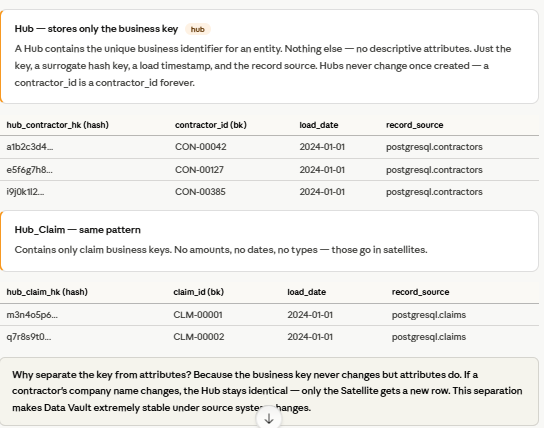

Step 1 — Build Hub_Contractor

A Hub has exactly 4 columns. Here's the code with every line explained:

In [8]:
conn.rollback()
cur = conn.cursor()

cur.execute("""
    CREATE TABLE hub_contractor (
        hub_contractor_hk  CHAR(32) PRIMARY KEY,
        contractor_id      VARCHAR(20) NOT NULL,
        load_date          TIMESTAMP NOT NULL,
        record_source      VARCHAR(50) NOT NULL
    )
""")

cur.execute("""
    INSERT INTO hub_contractor
    SELECT
        md5(contractor_id)        AS hub_contractor_hk,
        contractor_id             AS contractor_id,
        NOW()                     AS load_date,
        'postgresql.contractors'  AS record_source
    FROM contractors
""")

conn.commit()
cur.execute("SELECT COUNT(*) FROM hub_contractor")
print("Hub_Contractor rows:", cur.fetchone()[0])
cur.execute("SELECT * FROM hub_contractor LIMIT 3")
for r in cur.fetchall():
    print(r)

Hub_Contractor rows: 1500
('0a774ab778c420d29ce8f9670269aad5', 'CON-00001', datetime.datetime(2026, 6, 1, 4, 29, 33, 499265), 'postgresql.contractors')
('5a5e33a30b9a432c9ae08da3f5e17609', 'CON-00002', datetime.datetime(2026, 6, 1, 4, 29, 33, 499265), 'postgresql.contractors')
('24defc586f9beb5df3f6b41554111bec', 'CON-00003', datetime.datetime(2026, 6, 1, 4, 29, 33, 499265), 'postgresql.contractors')


Step 2 — Build Sat_Contractor_Details
A Satellite stores descriptive attributes. Key difference from a Hub — it has a load_date as part of the primary key (not just a column), because every change creates a new row with a new load_date.

In [9]:
cur.execute("""
    CREATE TABLE sat_contractor_details (
        hub_contractor_hk  CHAR(32) NOT NULL,
        load_date          TIMESTAMP NOT NULL,
        company_name       VARCHAR(200),
        trade              VARCHAR(100),
        state              VARCHAR(50),
        tier               VARCHAR(50),
        emr                NUMERIC(5,2),
        employees_count    INTEGER,
        record_source      VARCHAR(50),
        PRIMARY KEY (hub_contractor_hk, load_date)
    )
""")

cur.execute("""
    INSERT INTO sat_contractor_details
    SELECT
        md5(contractor_id)        AS hub_contractor_hk,
        NOW()                     AS load_date,
        company_name,
        trade,
        state,
        tier,
        emr,
        employees_count,
        'postgresql.contractors'  AS record_source
    FROM contractors
""")

conn.commit()
cur.execute("SELECT COUNT(*) FROM sat_contractor_details")
print("Sat_Contractor_Details rows:", cur.fetchone()[0])
cur.execute("""
    SELECT s.hub_contractor_hk, s.company_name, s.tier, s.emr, s.load_date
    FROM sat_contractor_details s
    LIMIT 3
""")
for r in cur.fetchall():
    print(r)

Sat_Contractor_Details rows: 1500
('0a774ab778c420d29ce8f9670269aad5', 'Premier Plumbing Development Corp', 'Preferred', Decimal('1.72'), datetime.datetime(2026, 6, 1, 4, 29, 33, 521447))
('5a5e33a30b9a432c9ae08da3f5e17609', 'Summit General Contractor Building Services', 'Standard', Decimal('0.55'), datetime.datetime(2026, 6, 1, 4, 29, 33, 521447))
('24defc586f9beb5df3f6b41554111bec', 'Premier Concrete Development Corp', 'Probationary', Decimal('0.78'), datetime.datetime(2026, 6, 1, 4, 29, 33, 521447))


Step 3 — Build Link_Claim_Contractor
A Link stores the relationship between two hubs. It contains the hash keys of both hubs it connects.

In [10]:
cur.execute("""
    CREATE TABLE hub_claim (
        hub_claim_hk   CHAR(32) PRIMARY KEY,
        claim_id       VARCHAR(20) NOT NULL,
        load_date      TIMESTAMP NOT NULL,
        record_source  VARCHAR(50) NOT NULL
    )
""")

cur.execute("""
    INSERT INTO hub_claim
    SELECT
        md5(claim_id)          AS hub_claim_hk,
        claim_id               AS claim_id,
        NOW()                  AS load_date,
        'postgresql.claims'    AS record_source
    FROM claims
""")

conn.commit()
print("Hub_Claim rows:", cur.execute("SELECT COUNT(*) FROM hub_claim") or cur.fetchone()[0])

Hub_Claim rows: 2500


Hub_Claim built. ✓ Now the Link table:

In [11]:
cur.execute("""
    CREATE TABLE link_claim_contractor (
        link_claim_contractor_hk  CHAR(32) PRIMARY KEY,
        hub_claim_hk              CHAR(32) NOT NULL,
        hub_contractor_hk         CHAR(32) NOT NULL,
        load_date                 TIMESTAMP NOT NULL,
        record_source             VARCHAR(50) NOT NULL
    )
""")

cur.execute("""
    INSERT INTO link_claim_contractor
    SELECT
        md5(cl.claim_id || ce.contractor_id)  AS link_claim_contractor_hk,
        md5(cl.claim_id)                      AS hub_claim_hk,
        md5(ce.contractor_id)                 AS hub_contractor_hk,
        NOW()                                 AS load_date,
        'postgresql.claims'                   AS record_source
    FROM claims cl
    JOIN wrap_programs wp ON cl.program_id = wp.program_id
    JOIN contractor_enrollments ce ON wp.program_id = ce.program_id
""")

conn.commit()
cur.execute("SELECT COUNT(*) FROM link_claim_contractor")
print("Link_Claim_Contractor rows:", cur.fetchone()[0])
cur.execute("SELECT * FROM link_claim_contractor LIMIT 3")
for r in cur.fetchall():
    print(r)

Link_Claim_Contractor rows: 74085
('cb5628e45215e3ce6b80d95c2f6b1f26', '6e6e5e3c919641f359c1101cebf16314', '70d562d9ef5aedfc0544d35b6a1d2761', datetime.datetime(2026, 6, 1, 4, 29, 39, 118943), 'postgresql.claims')
('e3b20bfff258e72126d903edc01f15dd', '6e6e5e3c919641f359c1101cebf16314', '1f27de71cab99a334275a40177b3913f', datetime.datetime(2026, 6, 1, 4, 29, 39, 118943), 'postgresql.claims')
('561c1e7a51b1191152dc23cab8a6832d', '6e6e5e3c919641f359c1101cebf16314', '353f162b45fde53a78c7e1110cfbc324', datetime.datetime(2026, 6, 1, 4, 29, 39, 118943), 'postgresql.claims')


In [12]:
import pandas as pd

query = """
    SELECT
        hc.contractor_id,
        s.company_name,
        s.tier,
        s.emr,
        COUNT(DISTINCT l.hub_claim_hk) AS total_claims
    FROM hub_contractor hc
    JOIN sat_contractor_details s
        ON hc.hub_contractor_hk = s.hub_contractor_hk
    JOIN link_claim_contractor l
        ON hc.hub_contractor_hk = l.hub_contractor_hk
    GROUP BY hc.contractor_id, s.company_name, s.tier, s.emr
    ORDER BY total_claims DESC
    LIMIT 10
"""

df = pd.read_sql(query, conn)
print(df.to_string(index=False))

/tmp/ipykernel_833/1738974723.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


contractor_id                            company_name         tier  emr  total_claims
    CON-00005   Central Landscaping Contractors Group  Conditional 1.46           175
    CON-00739            United Plumbing Projects Inc  Conditional 1.45           164
    CON-01367          Global Electrical Builders Inc Probationary 0.55           164
    CON-00483             Allied HVAC Construction Co     Standard 1.88           153
    CON-01405          Premier Steel Development Corp  Conditional 1.01           153
    CON-00243          Premier Glass Development Corp  Conditional 1.29           144
    CON-01473    Allied Landscaping Contractors Group Probationary 0.78           144
    CON-00632            Global Plumbing Projects Inc    Preferred 1.12           142
    CON-00076    American Plumbing Infrastructure LLC    Preferred 0.62           140
    CON-01332 Summit Fire Protection Construction LLC     Standard 0.51           136


"How many contractors are in each tier, according to the Data Vault?"

You need:

hub_contractor — for contractor identity

sat_contractor_details — for tier attribute

GROUP BY tier

COUNT contractors

In [13]:
import pandas as pd

query = """
    SELECT
        s.tier,
        COUNT(hc.contractor_id)
    FROM hub_contractor hc
    JOIN sat_contractor_details s
        ON hc.hub_contractor_hk = s.hub_contractor_hk
    GROUP BY s.tier
    LIMIT 10
"""

df = pd.read_sql(query, conn)
print(df.to_string(index=False))

        tier  count
Probationary    396
    Standard    353
 Conditional    384
   Preferred    367


/tmp/ipykernel_833/3791532940.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


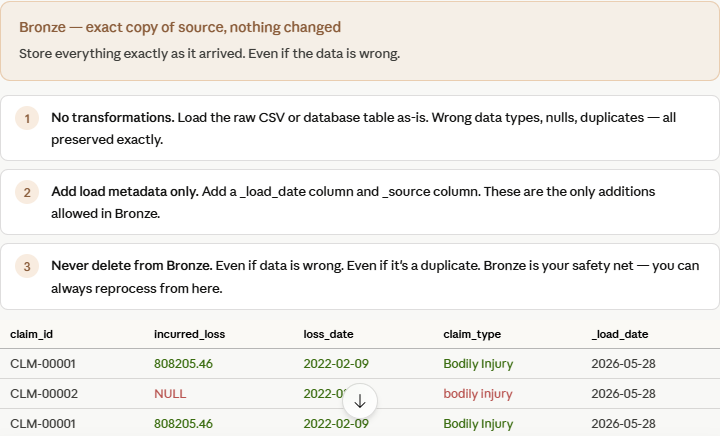

Step 1 — Bronze Layer

I'll show you the code with full explanation first, then you'll build Silver yourself.

In [14]:
import subprocess, time, psycopg2

subprocess.run('apt-get -qq install -y postgresql > /dev/null 2>&1', shell=True)
subprocess.run('service postgresql start > /dev/null 2>&1', shell=True)
time.sleep(3)
subprocess.run("""su postgres -c "psql -c \\"CREATE USER saas_user WITH PASSWORD 'saas_pass';\\" " """, shell=True, capture_output=True)
subprocess.run("""su postgres -c "psql -c \\"CREATE DATABASE novabuilds OWNER saas_user;\\" " """, shell=True, capture_output=True)
subprocess.run("""su postgres -c "psql -c \\"GRANT ALL PRIVILEGES ON DATABASE novabuilds TO saas_user;\\" " """, shell=True, capture_output=True)
exec(open('/content/novabuilds_colab_setup_v2.py').read())
conn = psycopg2.connect(host='localhost', port=5432, dbname='novabuilds', user='saas_user', password='saas_pass')
print("NovaBuild ready.")

Connected. Ready.
All 21 tables created.
Loading data...
  ✓ carriers                           15 rows
  ✓ brokers                            40 rows
  ✓ sponsors                           80 rows
  ✓ contractors                      1500 rows
  ✓ projects                          200 rows
  ✓ wrap_programs                     200 rows
  ✓ contractor_enrollments           6000 rows
  ✓ payroll_reports                 18000 rows
  ✓ policies                          600 rows
  ✓ policy_coverages                 1794 rows
  ✓ endorsements                      900 rows
  ✓ premiums                         4500 rows
  ✓ certificates                     9000 rows
  ✓ coi_verifications                9000 rows
  ✓ compliance_tracking              6000 rows
  ✓ prequalifications                1500 rows
  ✓ safety_incidents                 4000 rows
  ✓ inspections                      5000 rows
  ✓ claims                           2500 rows
  ✓ claim_assessments                2500 rows
  ✓

<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


  wrap_programs                     200
  contractor_enrollments          6,000
  payroll_reports                18,000
  policies                          600
  policy_coverages                1,794
  endorsements                      900
  premiums                        4,500
  certificates                    9,000
  coi_verifications               9,000
  compliance_tracking             6,000
  prequalifications               1,500
  safety_incidents                4,000
  inspections                     5,000
  claims                          2,500
  claim_assessments               2,500
  claim_payments                  3,200
----------------------------------------
  TOTAL                          76,529

── COI Compliance Rate by Contractor Tier ──


,tier,total_verifications,compliant,compliance_rate_pct
0,Conditional,2308,1442,62.5
1,Probationary,2437,1513,62.1
2,Preferred,2135,1311,61.4
3,Standard,2120,1285,60.6



── Loss Ratio by Project Type ──


...

,project_type,claim_count,premium_collected_m,incurred_loss_m,loss_ratio_pct
0,School,178,810.84,1155.64,142.5
1,Highway,230,1092.16,1460.01,133.7
2,Data Center,280,1484.33,1919.58,129.3
3,Industrial Facility,264,1132.17,1434.62,126.7
4,Hospital,276,1257.97,1500.13,119.2
5,Bridge,253,1290.77,1428.42,110.7
6,Residential Tower,219,1140.07,1244.48,109.2
7,Commercial Office,289,1329.93,1435.31,107.9
8,Mixed-Use,244,1184.19,1259.70,106.4
9,Retail Complex,267,1445.01,1450.43,100.4



── Contractors with COIs Expiring in 30 Days ──


<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


,company_name,trade,certificate_number,expiration_date,days_until_expiry,last_verification_result



Dataset ready. All queries working.
NovaBuild ready.


Step 1 — Bronze Layer

I'll show you the code with full explanation first, then you'll build Silver yourself.

In [15]:
import pandas as pd
import os
from datetime import datetime

# Create folder structure
os.makedirs('/content/bronze', exist_ok=True)
os.makedirs('/content/silver', exist_ok=True)
os.makedirs('/content/gold', exist_ok=True)
print("Folders created: bronze/ silver/ gold/")

# Load all 21 tables from PostgreSQL into Bronze
# Bronze rule: load as-is, add only _load_date and _source

tables = [
    'contractors', 'claims', 'projects', 'wrap_programs', 'policies',
    'premiums', 'certificates', 'coi_verifications', 'safety_incidents',
    'inspections', 'payroll_reports', 'claim_assessments', 'claim_payments',
    'brokers', 'carriers', 'sponsors', 'contractor_enrollments',
    'compliance_tracking', 'prequalifications', 'endorsements', 'policy_coverages'
]

for table in tables:
    # Load raw from PostgreSQL - no transformation
    df = pd.read_sql(f"SELECT * FROM {table}", conn)

    # Add only metadata columns - the only thing allowed in Bronze
    df['_load_date'] = datetime.now()
    df['_source'] = f'postgresql.{table}'

    # Save as Parquet - columnar format, efficient storage
    df.to_parquet(f'/content/bronze/{table}.parquet', index=False)
    print(f"Bronze: {table} — {len(df)} rows")

print("\nBronze layer complete.")

Folders created: bronze/ silver/ gold/


/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)


Bronze: contractors — 1500 rows


/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)


Bronze: claims — 2500 rows
Bronze: projects — 200 rows
Bronze: wrap_programs — 200 rows
Bronze: policies — 600 rows


...

/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)


Bronze: payroll_reports — 18000 rows
Bronze: claim_assessments — 2500 rows
Bronze: claim_payments — 3200 rows
Bronze: brokers — 40 rows
Bronze: carriers — 15 rows
Bronze: sponsors — 80 rows
Bronze: contractor_enrollments — 6000 rows


/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string 

Bronze: compliance_tracking — 6000 rows
Bronze: prequalifications — 1500 rows
Bronze: endorsements — 900 rows
Bronze: policy_coverages — 1794 rows

Bronze layer complete.


/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)
/tmp/ipykernel_833/1213248702.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table}", conn)


Step 2 — Silver Layer

Now I'll show you the Silver transformation for 3 key tables with full explanation. Then you'll write Silver for one table yourself.

In [16]:
from datetime import datetime

# ── Silver: contractors ──────────────────────────────────────────
bronze_contractors = pd.read_parquet('/content/bronze/contractors.parquet')

silver_contractors = bronze_contractors.copy()

# 1. Cast emr to float — Bronze may store it as object/string
silver_contractors['emr'] = pd.to_numeric(silver_contractors['emr'], errors='coerce')

# 2. Standardise tier — ensure consistent casing
silver_contractors['tier'] = silver_contractors['tier'].str.strip().str.title()

# 3. Fill null emr with median — can't drop rows, contractor may still have claims
silver_contractors['emr'] = silver_contractors['emr'].fillna(
    silver_contractors['emr'].median()
)

# 4. Remove duplicates — keep first occurrence of each contractor_id
silver_contractors = silver_contractors.drop_duplicates(subset=['contractor_id'])

# 5. Drop Bronze metadata columns — Silver has its own
silver_contractors = silver_contractors.drop(columns=['_load_date', '_source'])

# 6. Add Silver metadata
silver_contractors['_silver_load_date'] = datetime.now()

silver_contractors.to_parquet('/content/silver/contractors.parquet', index=False)
print(f"Silver contractors: {len(silver_contractors)} rows")
print(silver_contractors[['contractor_id','company_name','tier','emr']].head(3))


# ── Silver: claims ───────────────────────────────────────────────
bronze_claims = pd.read_parquet('/content/bronze/claims.parquet')

silver_claims = bronze_claims.copy()

# 1. Cast incurred_loss to float
silver_claims['incurred_loss'] = pd.to_numeric(
    silver_claims['incurred_loss'], errors='coerce'
)

# 2. Fill null incurred_loss with 0 — no loss recorded means 0
silver_claims['incurred_loss'] = silver_claims['incurred_loss'].fillna(0)

# 3. Cast loss_date to datetime
silver_claims['loss_date'] = pd.to_datetime(
    silver_claims['loss_date'], errors='coerce'
)

# 4. Standardise claim_type casing
silver_claims['claim_type'] = silver_claims['claim_type'].str.strip().str.title()

# 5. Drop rows with null claim_id — unresolvable without a key
silver_claims = silver_claims.dropna(subset=['claim_id'])

# 6. Remove duplicates
silver_claims = silver_claims.drop_duplicates(subset=['claim_id'])

silver_claims = silver_claims.drop(columns=['_load_date','_source'])
silver_claims['_silver_load_date'] = datetime.now()

silver_claims.to_parquet('/content/silver/claims.parquet', index=False)
print(f"\nSilver claims: {len(silver_claims)} rows")
print(silver_claims[['claim_id','claim_type','incurred_loss','loss_date']].head(3))


# ── Silver: coi_verifications ────────────────────────────────────
bronze_coi = pd.read_parquet('/content/bronze/coi_verifications.parquet')

silver_coi = bronze_coi.copy()

# 1. Standardise result to exact allowed values
allowed_results = ['Compliant', 'Deficient', 'Non-Compliant', 'Pending Review']
silver_coi['result'] = silver_coi['result'].str.strip().str.title()
silver_coi['result'] = silver_coi['result'].where(
    silver_coi['result'].isin(allowed_results), other='Pending Review'
)

# 2. Cast verification_date to datetime
silver_coi['verification_date'] = pd.to_datetime(
    silver_coi['verification_date'], errors='coerce'
)

# 3. Remove duplicates
silver_coi = silver_coi.drop_duplicates(subset=['verification_id'])

silver_coi = silver_coi.drop(columns=['_load_date','_source'])
silver_coi['_silver_load_date'] = datetime.now()

silver_coi.to_parquet('/content/silver/coi_verifications.parquet', index=False)
print(f"\nSilver coi_verifications: {len(silver_coi)} rows")
print(silver_coi['result'].value_counts())

Silver contractors: 1500 rows
  contractor_id                                 company_name          tier  \
0     CON-00001            Premier Plumbing Development Corp     Preferred   
1     CON-00002  Summit General Contractor Building Services      Standard   
2     CON-00003            Premier Concrete Development Corp  Probationary   

    emr  
0  1.72  
1  0.55  
2  0.78  

Silver claims: 2500 rows
    claim_id       claim_type  incurred_loss  loss_date
0  CLM-00001     Workers Comp      120752.80 2022-11-20
1  CLM-00002     Water Damage     1096690.44 2024-03-16
2  CLM-00003  Equipment Theft      225475.90 2021-07-01

Silver coi_verifications: 9000 rows
result
Compliant         5551
Non-Compliant     1628
Deficient         1092
Pending Review     729
Name: count, dtype: int64


In [17]:
# ── Silver: safety_incident ──────────────────────────────────────────
bronze_safety_incedent = pd.read_parquet('/content/bronze/safety_incidents.parquet')
silver_safety_incedent = bronze_safety_incedent.copy()

#Cast incident_date to datetime
silver_safety_incedent['incident_date'] = pd.to_datetime(
    silver_safety_incedent['incident_date'], errors='coerce')

#Standardise incident_type casing using str.strip().str.title()
silver_safety_incedent['incident_type'] = silver_safety_incedent['incident_type'].str.strip().str.title()

#Remove duplicates on incident_id
silver_safety_incedent = silver_safety_incedent.drop_duplicates(subset=['incident_id'])

#Drop _load_date and _source
silver_safety_incedent = silver_safety_incedent.drop(columns=['_load_date', '_source'])

#Add _silver_load_date
silver_safety_incedent['_silver_load_date'] = datetime.now()

#Save to /content/silver/safety_incidents.parquet
silver_safety_incedent.to_parquet('/content/silver/safety_incident.parquet', index=False)
print(f"Silver Safety_incident: {len(silver_safety_incedent)} rows")
print(silver_safety_incedent[['incident_id','incident_type','incident_date']].head(3))

Silver Safety_incident: 4000 rows
  incident_id      incident_type incident_date
0   INC-00001  Caught In/Between    2022-07-30
1   INC-00002   Vehicle Accident    2021-07-24
2   INC-00003   Struck By Object    2023-01-10


Step 3 — Gold Layer

I'll show you Gold for the most important table — gold_contractor_risk. This joins Silver tables and applies business logic.

In [18]:
# ── Gold: contractor_risk_profile ───────────────────────────────
# Read from Silver -- Gold always reads from Silver, never Bronze

silver_contractors = pd.read_parquet('/content/silver/contractors.parquet')
silver_claims      = pd.read_parquet('/content/silver/claims.parquet')
silver_coi         = pd.read_parquet('/content/silver/coi_verifications.parquet')
silver_enrollments = pd.read_parquet('/content/bronze/contractor_enrollments.parquet')
silver_programs    = pd.read_parquet('/content/bronze/wrap_programs.parquet')

# Step 1: Get contractor_id into claims via enrollment path
# claims -> wrap_programs -> contractor_enrollments -> contractors
claims_with_program = silver_claims.merge(
    silver_programs[['program_id','project_id']],
    on='program_id', how='left'
)

claims_with_contractor = claims_with_program.merge(
    silver_enrollments[['program_id','contractor_id']],
    on='program_id', how='left'
)

# Step 2: Aggregate claims per contractor
claim_summary = claims_with_contractor.groupby('contractor_id').agg(
    total_claims    = ('claim_id', 'count'),
    total_loss      = ('incurred_loss', 'sum'),
    avg_loss        = ('incurred_loss', 'mean'),
    max_loss        = ('incurred_loss', 'max')
).reset_index()

# Step 3: Get COI deficiency rate per contractor
# Need contractor_id in coi_verifications via certificates
bronze_certs = pd.read_parquet('/content/bronze/certificates.parquet')
coi_with_contractor = silver_coi.merge(
    bronze_certs[['certificate_id','contractor_id']],
    on='certificate_id', how='left'
)

# coi_verifications already has contractor_id -- no certificates merge needed
coi_summary = silver_coi.groupby('contractor_id').agg(
    total_coi_checks  = ('verification_id', 'count'),
    deficient_cois    = ('result', lambda x: (x.isin(['Deficient','Non-Compliant'])).sum())
).reset_index()

coi_summary['coi_deficiency_rate'] = (
    coi_summary['deficient_cois'] / coi_summary['total_coi_checks'] * 100
).round(2)

# Step 4: Join everything to contractors
gold = silver_contractors.merge(claim_summary, on='contractor_id', how='left')
gold = gold.merge(coi_summary[['contractor_id','total_coi_checks',
                                'coi_deficiency_rate']], on='contractor_id', how='left')

# Step 5: Risk Flag
gold['risk_flag'] = gold['emr'].apply(
    lambda x: 'Critical' if x >= 1.5 else
              'High'     if x >= 1.2 else
              'Medium'   if x >= 1.0 else 'Low'
)

# Step 6: Fill nulls
gold['total_claims'] = gold['total_claims'].fillna(0).astype(int)
gold['total_loss']   = gold['total_loss'].fillna(0).round(2)
gold['avg_loss']     = gold['avg_loss'].fillna(0).round(2)

# Step 7: Gold metadata
gold['_gold_load_date'] = datetime.now()

gold.to_parquet('/content/gold/contractor_risk_profile.parquet', index=False)
print(f"Gold contractor_risk_profile: {len(gold)} rows")
print(gold[['contractor_id','company_name','tier','emr','risk_flag',
            'total_claims','total_loss','coi_deficiency_rate']].head(5).to_string(index=False))

Gold contractor_risk_profile: 1500 rows
contractor_id                                company_name         tier  emr risk_flag  total_claims   total_loss  coi_deficiency_rate
    CON-00001           Premier Plumbing Development Corp    Preferred 1.72  Critical            18  15643575.19                20.00
    CON-00002 Summit General Contractor Building Services     Standard 0.55       Low            58  46613344.91                44.44
    CON-00003           Premier Concrete Development Corp Probationary 0.78       Low            59  46730491.67                25.00
    CON-00004             Global Elevator Construction Co  Conditional 1.49      High            35  30144396.21                 0.00
    CON-00005       Central Landscaping Contractors Group  Conditional 1.46      High           175 127090195.84                30.77


Build gold_monthly_loss yourself.

This is a monthly aggregation of claims for the line chart in Power BI.

In [19]:
#Read from /content/silver/claims.parquet
silver_claims = pd.read_parquet('/content/silver/claims.parquet')

#Extract year and month from loss_date:
silver_claims['year'] = silver_claims['loss_date'].dt.year
silver_claims['month'] = silver_claims['loss_date'].dt.month

#Group by year and month

#Aggregate: total_claims = count of claim_id, total_loss = sum of incurred_loss
gold_monthly = silver_claims.groupby(['year' , 'month']).agg(
    total_claims    = ('claim_id', 'count'),
    total_loss      = ('incurred_loss', 'sum')
    ).reset_index()

#Sort by year then month ascending
gold_monthly = gold_monthly.sort_values(['year', 'month'], ascending= [True, True])
# Add _gold_load_date column
gold_monthly['_gold_load_date'] = datetime.now()

gold_monthly.to_parquet('/content/gold/monthly_loss.parquet', index=False)

print(f"Gold monthly_loss: {len(gold_monthly)} rows")
print(gold_monthly.head(6).to_string(index=False))

Gold monthly_loss: 48 rows
 year  month  total_claims  total_loss            _gold_load_date
 2020     12             1   175639.60 2026-06-01 04:30:51.143620
 2021      1             2  1968152.08 2026-06-01 04:30:51.143620
 2021      2             1  1981510.36 2026-06-01 04:30:51.143620
 2021      3             7  2989397.11 2026-06-01 04:30:51.143620
 2021      4             7  7241233.35 2026-06-01 04:30:51.143620
 2021      5            11  5678376.97 2026-06-01 04:30:51.143620


In [ ]:
# Check columns in coi_verifications and certificates
print("coi_verifications columns:", silver_coi.columns.tolist())
print("certificates columns:", bronze_certs.columns.tolist())
print("claims", silver_claims.columns.tolist())

coi_verifications columns: ['verification_id', 'certificate_id', 'contractor_id', 'project_id', 'verification_date', 'verified_by', 'result', 'gl_compliant', 'wc_compliant', 'auto_compliant', 'umbrella_compliant', 'deficiency_notes', 'review_time_minutes', 'follow_up_required', 'resolved_date', 'created_at', '_silver_load_date']
certificates columns: ['certificate_id', 'enrollment_id', 'contractor_id', 'project_id', 'certificate_number', 'issuing_agent', 'holder_name', 'issue_date', 'expiration_date', 'gl_limit', 'wc_limit', 'auto_limit', 'umbrella_limit', 'status', 'submitted_via', 'created_at', '_load_date', '_source']
claims ['claim_id', 'claim_number', 'policy_id', 'program_id', 'project_id', 'carrier_id', 'loss_date', 'report_date', 'claim_type', 'coverage_line', 'claimant_name', 'claimant_type', 'description', 'reserves', 'incurred_loss', 'status', 'adjuster_name', 'litigation', 'subrogation_potential', 'created_at', '_silver_load_date', 'year', 'month']


Good. Section 6.5 — Data Mesh.

No SQL or Python for this one. It's a design exercise — diagram + document.

What is Data Mesh?

Data Mesh is a different way of organising data ownership in a company. Instead of one central data team owning all data, each business domain owns its own data and publishes it as a data product for others to consume.

The problem it solves:
In NovaBuild's case — imagine one central DE team owns all 21 tables. Every time the Claims team needs a new report, they raise a ticket to the central DE team. The COI team does the same. The Safety team does the same. The central team becomes a bottleneck — 3 domains waiting for one team.
Data Mesh solution: each domain owns and serves its own data.

In [20]:
xml = '''<?xml version="1.0" encoding="UTF-8"?>
<mxGraphModel><root><mxCell id="0"/><mxCell id="1" parent="0"/>

<!-- TITLE -->
<mxCell id="t1" value="NovaBuild — Data Mesh Architecture" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;fontSize=16;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="200" y="10" width="500" height="30" as="geometry"/></mxCell>

<!-- CONTRACTOR DOMAIN -->
<mxCell id="d1" value="Contractor Domain" style="swimlane;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=13;fontStyle=1;startSize=30;" vertex="1" parent="1"><mxGeometry x="20" y="60" width="200" height="280" as="geometry"/></mxCell>
<mxCell id="d1t1" value="contractors" style="rounded=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="105" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d1t2" value="contractor_enrollments" style="rounded=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="143" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d1t3" value="prequalifications" style="rounded=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="181" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d1t4" value="payroll_reports" style="rounded=1;fillColor=#dae8fc;strokeColor=#6c8ebf;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="219" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d1p1" value="&#x1F4E6; contractor_risk_profile" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=10;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="40" y="270" width="160" height="28" as="geometry"/></mxCell>

<!-- CLAIMS DOMAIN -->
<mxCell id="d2" value="Claims Domain" style="swimlane;fillColor=#f8cecc;strokeColor=#b85450;fontSize=13;fontStyle=1;startSize=30;" vertex="1" parent="1"><mxGeometry x="680" y="60" width="200" height="280" as="geometry"/></mxCell>
<mxCell id="d2t1" value="claims" style="rounded=1;fillColor=#f8cecc;strokeColor=#b85450;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="105" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d2t2" value="claim_assessments" style="rounded=1;fillColor=#f8cecc;strokeColor=#b85450;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="143" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d2t3" value="claim_payments" style="rounded=1;fillColor=#f8cecc;strokeColor=#b85450;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="181" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d2t4" value="policies" style="rounded=1;fillColor=#f8cecc;strokeColor=#b85450;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="219" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d2p1" value="&#x1F4E6; loss_ratio_report" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=10;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="700" y="270" width="160" height="28" as="geometry"/></mxCell>

<!-- COMPLIANCE DOMAIN -->
<mxCell id="d3" value="Compliance Domain" style="swimlane;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=13;fontStyle=1;startSize=30;" vertex="1" parent="1"><mxGeometry x="20" y="400" width="200" height="280" as="geometry"/></mxCell>
<mxCell id="d3t1" value="coi_verifications" style="rounded=1;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="445" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d3t2" value="certificates" style="rounded=1;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="483" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d3t3" value="compliance_tracking" style="rounded=1;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="521" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d3t4" value="endorsements" style="rounded=1;fillColor=#d5e8d4;strokeColor=#82b366;fontSize=11;" vertex="1" parent="1"><mxGeometry x="40" y="559" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d3p1" value="&#x1F4E6; coi_status_feed" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=10;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="40" y="610" width="160" height="28" as="geometry"/></mxCell>

<!-- SAFETY DOMAIN -->
<mxCell id="d4" value="Safety Domain" style="swimlane;fillColor=#e1d5e7;strokeColor=#9673a6;fontSize=13;fontStyle=1;startSize=30;" vertex="1" parent="1"><mxGeometry x="680" y="400" width="200" height="280" as="geometry"/></mxCell>
<mxCell id="d4t1" value="safety_incidents" style="rounded=1;fillColor=#e1d5e7;strokeColor=#9673a6;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="445" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d4t2" value="inspections" style="rounded=1;fillColor=#e1d5e7;strokeColor:#9673a6;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="483" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d4t3" value="wrap_programs" style="rounded=1;fillColor=#e1d5e7;strokeColor=#9673a6;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="521" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d4t4" value="projects" style="rounded=1;fillColor=#e1d5e7;strokeColor=#9673a6;fontSize=11;" vertex="1" parent="1"><mxGeometry x="700" y="559" width="160" height="28" as="geometry"/></mxCell>
<mxCell id="d4p1" value="&#x1F4E6; osha_recordable_rate" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=10;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="700" y="610" width="160" height="28" as="geometry"/></mxCell>

<!-- CENTRAL PLATFORM -->
<mxCell id="cp" value="Data Platform Infrastructure&#xa;(dbt + Airflow + Azure)" style="rounded=1;fillColor=#f5f5f5;strokeColor=#666666;fontSize=12;fontStyle=1;" vertex="1" parent="1"><mxGeometry x="300" y="300" width="300" height="60" as="geometry"/></mxCell>

<!-- ARROWS - domain to platform -->
<mxCell id="a1" edge="1" source="d1p1" target="cp" style="dashed=1;endArrow=open;strokeColor=#6c8ebf;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="a2" edge="1" source="d2p1" target="cp" style="dashed=1;endArrow=open;strokeColor=#b85450;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="a3" edge="1" source="d3p1" target="cp" style="dashed=1;endArrow=open;strokeColor=#82b366;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="a4" edge="1" source="d4p1" target="cp" style="dashed=1;endArrow=open;strokeColor=#9673a6;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- CONSUMERS -->
<mxCell id="c1" value="Power BI&#xa;(Actuaries)" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=11;" vertex="1" parent="1"><mxGeometry x="300" y="430" width="120" height="50" as="geometry"/></mxCell>
<mxCell id="c2" value="SAP Analytics&#xa;Cloud" style="rounded=1;fillColor=#fff2cc;strokeColor=#d6b656;fontSize=11;" vertex="1" parent="1"><mxGeometry x="480" y="430" width="120" height="50" as="geometry"/></mxCell>
<mxCell id="a5" edge="1" source="cp" target="c1" style="endArrow=block;strokeColor=#666666;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>
<mxCell id="a6" edge="1" source="cp" target="c2" style="endArrow=block;strokeColor=#666666;" parent="1"><mxGeometry relative="1" as="geometry"/></mxCell>

<!-- LEGEND -->
<mxCell id="leg1" value="&#x1F4E6; = Data Product (published API/dataset)" style="text;html=1;strokeColor=none;fillColor=#fff2cc;fontSize=11;rounded=1;" vertex="1" parent="1"><mxGeometry x="300" y="530" width="300" height="28" as="geometry"/></mxCell>
<mxCell id="leg2" value="--- = Data Product consumed by platform" style="text;html=1;strokeColor=none;fillColor=none;fontSize=11;" vertex="1" parent="1"><mxGeometry x="300" y="565" width="300" height="28" as="geometry"/></mxCell>

</root></mxGraphModel>'''

with open('/content/novabuild_data_mesh.drawio', 'w') as f:
    f.write(xml)
print("File saved: /content/novabuild_data_mesh.drawio")
print("Download from Files panel on the left sidebar")

File saved: /content/novabuild_data_mesh.drawio
Download from Files panel on the left sidebar


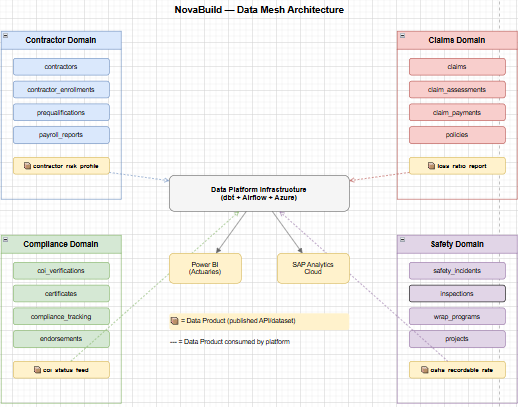

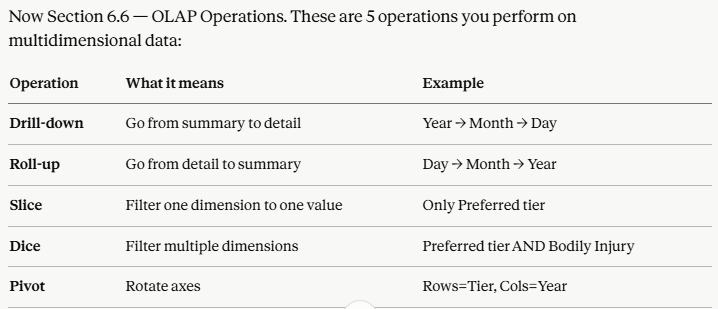

In [21]:
import pandas as pd

# Load Gold for OLAP operations
gold_risk = pd.read_parquet('/content/gold/contractor_risk_profile.parquet')
silver_claims = pd.read_parquet('/content/silver/claims.parquet')
silver_contractors = pd.read_parquet('/content/silver/contractors.parquet')
silver_enrollments = pd.read_parquet('/content/bronze/contractor_enrollments.parquet')
silver_programs = pd.read_parquet('/content/bronze/wrap_programs.parquet')

# Build a base joined DataFrame for OLAP operations
claims_full = silver_claims.merge(
    silver_programs[['program_id']], on='program_id', how='left'
).merge(
    silver_enrollments[['program_id','contractor_id']], on='program_id', how='left'
).merge(
    silver_contractors[['contractor_id','tier']], on='contractor_id', how='left'
)

claims_full['year']  = claims_full['loss_date'].dt.year
claims_full['month'] = claims_full['loss_date'].dt.month

print("Base DataFrame ready.")
print(f"Rows: {len(claims_full)}")
print(claims_full[['claim_id','tier','claim_type','incurred_loss','year','month']].head(3).to_string(index=False))

Base DataFrame ready.
Rows: 74085
 claim_id        tier   claim_type  incurred_loss  year  month
CLM-00001   Preferred Workers Comp       120752.8  2022     11
CLM-00001 Conditional Workers Comp       120752.8  2022     11
CLM-00001 Conditional Workers Comp       120752.8  2022     11


Operation 1 — Drill-down

Going from Year summary → Month detail:

In [22]:
print("=== DRILL-DOWN: Year -> Month ===")
print()

# Level 1: Year summary (rolled up)
year_summary = claims_full.groupby('year').agg(
    total_claims = ('claim_id', 'nunique'),
    total_loss   = ('incurred_loss', 'sum')
).reset_index()
print("Level 1 — Year:")
print(year_summary.to_string(index=False))

print()

# Level 2: Drill down into 2023 by month
month_detail = claims_full[claims_full['year'] == 2023].groupby(
    ['year','month']
).agg(
    total_claims = ('claim_id', 'nunique'),
    total_loss   = ('incurred_loss', 'sum')
).reset_index()
print("Level 2 — Drill down into 2023 by Month:")
print(month_detail.to_string(index=False))

=== DRILL-DOWN: Year -> Month ===

Level 1 — Year:
 year  total_claims   total_loss
 2020             1 6.323026e+06
 2021           201 4.346390e+09
 2022           603 1.298364e+10
 2023           791 1.726236e+10
 2024           904 2.221200e+10

Level 2 — Drill down into 2023 by Month:
 year  month  total_claims   total_loss
 2023      1            65 1.525069e+09
 2023      2            55 1.225042e+09
 2023      3            70 1.459011e+09
 2023      4            54 1.184389e+09
 2023      5            54 1.089929e+09
 2023      6            69 1.816686e+09
 2023      7            71 1.735794e+09
 2023      8            78 1.789704e+09
 2023      9            64 1.396461e+09
 2023     10            71 1.398167e+09
 2023     11            73 1.246183e+09
 2023     12            67 1.395922e+09


Operation 2 — Roll-up

Roll-up is the opposite of drill-down. Go from Month detail → Quarter summary → Year summary.


In [23]:
print("=== ROLL-UP: Month -> Quarter -> Year ===")
print()

# Start at Month level (most detailed)
monthly = claims_full.groupby(['year','month']).agg(
    total_claims = ('claim_id','nunique'),
    total_loss   = ('incurred_loss','sum')
).reset_index()

# Roll up to Quarter
monthly['quarter'] = ((monthly['month'] - 1) // 3) + 1

quarterly = monthly.groupby(['year','quarter']).agg(
    total_claims = ('total_claims','sum'),
    total_loss   = ('total_loss','sum')
).reset_index()

print("Rolled up to Quarter:")
print(quarterly[quarterly['year']==2023].to_string(index=False))

print()

# Roll up further to Year
yearly = quarterly.groupby('year').agg(
    total_claims = ('total_claims','sum'),
    total_loss   = ('total_loss','sum')
).reset_index()

print("Rolled up to Year:")
print(yearly.to_string(index=False))

=== ROLL-UP: Month -> Quarter -> Year ===

Rolled up to Quarter:
 year  quarter  total_claims   total_loss
 2023        1           190 4.209122e+09
 2023        2           177 4.091004e+09
 2023        3           213 4.921960e+09
 2023        4           211 4.040273e+09

Rolled up to Year:
 year  total_claims   total_loss
 2020             1 6.323026e+06
 2021           201 4.346390e+09
 2022           603 1.298364e+10
 2023           791 1.726236e+10
 2024           904 2.221200e+10


Operation 3 — Slice

Slice = filter one dimension to one value. Like a slicer in Power BI.

In [24]:
print("=== SLICE: Only Preferred tier ===")
print()

# Slice: keep only one value from tier dimension
sliced = claims_full[claims_full['tier'] == 'Preferred']

result = sliced.groupby('year').agg(
    total_claims = ('claim_id','nunique'),
    total_loss   = ('incurred_loss','sum')
).reset_index()

print(f"Total rows after slice: {len(sliced)} (from {len(claims_full)})")
print()
print("Preferred tier claims by year:")
print(result.to_string(index=False))

=== SLICE: Only Preferred tier ===

Total rows after slice: 18078 (from 74085)

Preferred tier claims by year:
 year  total_claims   total_loss
 2020             1 1.580756e+06
 2021           201 1.092851e+09
 2022           603 3.260622e+09
 2023           791 4.166800e+09
 2024           904 5.372333e+09


Operation 4 — Dice

Dice = filter multiple dimensions simultaneously. Slice filters one dimension, Dice filters two or more.

In [25]:
print("=== DICE: Preferred tier AND Bodily Injury AND year 2023 ===")
print()

# Dice: multiple dimension filters at once
diced = claims_full[
    (claims_full['tier'] == 'Preferred') &
    (claims_full['claim_type'] == 'Bodily Injury') &
    (claims_full['year'] == 2023)
]

result = diced.groupby(['tier','claim_type','year']).agg(
    total_claims = ('claim_id','nunique'),
    total_loss   = ('incurred_loss','sum')
).reset_index()

print(f"Total rows after dice: {len(diced)} (from {len(claims_full)})")
print()
print(result.to_string(index=False))

=== DICE: Preferred tier AND Bodily Injury AND year 2023 ===

Total rows after dice: 1005 (from 74085)

     tier    claim_type  year  total_claims   total_loss
Preferred Bodily Injury  2023           143 704829550.35


Operation 5 — Pivot

Pivot = rotate the data so one dimension becomes columns instead of rows. Classic cross-tab view.

In [26]:
print("=== PIVOT: Tier as rows, Year as columns, Total Loss as values ===")
print()

# First aggregate
pivot_data = claims_full.groupby(['tier','year']).agg(
    total_loss = ('incurred_loss','sum')
).reset_index()

# Pivot -- tier on rows, year on columns
pivot_table = pivot_data.pivot(
    index='tier',
    columns='year',
    values='total_loss'
).fillna(0)

# Format numbers
pivot_table = pivot_table.applymap(lambda x: f"{x:,.0f}")

print(pivot_table.to_string())

=== PIVOT: Tier as rows, Year as columns, Total Loss as values ===

year               2020           2021           2022           2023           2024
tier                                                                               
Conditional     878,198  1,084,346,384  3,347,013,387  4,427,881,469  5,687,361,695
Preferred     1,580,756  1,092,851,438  3,260,621,960  4,166,800,202  5,372,333,180
Probationary  2,458,954  1,144,964,932  3,436,816,151  4,538,165,012  5,747,733,872
Standard      1,405,117  1,024,227,149  2,939,190,211  4,129,511,452  5,404,569,272


/tmp/ipykernel_833/2545420038.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_table = pivot_table.applymap(lambda x: f"{x:,.0f}")


Section 6.7 —

Aggregate Tables is next. This is the shortest section — building pre-aggregated summary tables in PostgreSQL so Power BI doesn't have to compute them at query time.

What is a pre-aggregate table and why does it exist?

Every time Power BI renders a visual, it runs a query. If Power BI has to scan 76,529 raw rows and join 4 tables to show "monthly loss trend" — it does that every single time a user opens the dashboard. 10 users = 10 full scans simultaneously.
A pre-aggregate table runs that heavy query ONCE, stores the result, and Power BI reads the small summary table instead. Monthly loss trend = 48 rows instead of 76,529.


In real DE work this is called a summary table or aggregate table. In dbt (Module 7) these become your mart models. In Azure (Module 11) these sit in the Gold layer of ADLS Gen2.

In [27]:
conn.rollback()
cur = conn.cursor()

# Drop if exists (clean rebuild)
cur.execute("DROP TABLE IF EXISTS agg_monthly_claim_summary")

# Create and populate in one statement
cur.execute("""
    CREATE TABLE agg_monthly_claim_summary AS
    SELECT
        EXTRACT(YEAR  FROM c.loss_date)::INT   AS year,
        EXTRACT(MONTH FROM c.loss_date)::INT   AS month,
        TO_CHAR(c.loss_date, 'YYYY-MM')        AS year_month,
        c.claim_type,
        COUNT(DISTINCT c.claim_id)             AS total_claims,
        SUM(c.incurred_loss)                   AS total_loss,
        AVG(c.incurred_loss)                   AS avg_loss,
        SUM(c.reserves)                        AS total_reserves
    FROM claims c
    GROUP BY
        EXTRACT(YEAR  FROM c.loss_date),
        EXTRACT(MONTH FROM c.loss_date),
        TO_CHAR(c.loss_date, 'YYYY-MM'),
        c.claim_type
    ORDER BY year, month, claim_type
""")

conn.commit()
cur.execute("SELECT COUNT(*) FROM agg_monthly_claim_summary")
print("agg_monthly_claim_summary rows:", cur.fetchone()[0])

# Preview
cur.execute("""
    SELECT year, month, claim_type, total_claims, total_loss
    FROM agg_monthly_claim_summary
    ORDER BY year, month
    LIMIT 5
""")
print()
print(f"{'Year':<6} {'Month':<7} {'Claim Type':<22} {'Claims':>8} {'Total Loss':>15}")
print("-"*60)
for r in cur.fetchall():
    print(f"{r[0]:<6} {r[1]:<7} {r[2]:<22} {r[3]:>8} {r[4]:>15,.0f}")

agg_monthly_claim_summary rows: 304

Year   Month   Claim Type               Claims      Total Loss
------------------------------------------------------------
2020   12      Bodily Injury                 1         175,640
2021   1       Equipment Theft               1         676,251
2021   1       Bodily Injury                 1       1,291,901
2021   2       Bodily Injury                 1       1,981,510
2021   3       Bodily Injury                 1         508,877


Your turn — Table 2: agg_contractor_risk_summary

In [28]:
conn.rollback()
cur = conn.cursor()

# Drop if exists (clean rebuild)
cur.execute("DROP TABLE IF EXISTS agg_contractor_risk_summary")

# Create and populate in one statement
cur.execute("""
    CREATE TABLE agg_contractor_risk_summary AS
    SELECT
      c.contractor_id,
      c.company_name,
      c.tier,
      c.emr,
      COUNT(DISTINCT cl.claim_id) AS total_claims,
      SUM(cl.incurred_loss)  AS total_loss,
      AVG(cl.incurred_loss)  AS avg_loss
    FROM claims cl
    JOIN wrap_programs wp
      ON cl.program_id = wp.program_id
    JOIN contractor_enrollments ce
      ON ce.program_id = wp.program_id
    JOIN contractors c
      ON ce.contractor_id = c.contractor_id
    GROUP BY c.contractor_id, c.company_name, c.tier, c.emr
""")

conn.commit()
cur.execute("SELECT COUNT(*) FROM agg_contractor_risk_summary")
print("agg_contractor_risk_summary rows:", cur.fetchone()[0])

cur.execute("""
    SELECT contractor_id, company_name, tier, emr,
           total_claims, total_loss, avg_loss
    FROM agg_contractor_risk_summary
    ORDER BY total_loss DESC
    LIMIT 5
""")
print()
print(f"{'ID':<12} {'Company':<35} {'Tier':<14} {'EMR':<6} {'Claims':>8} {'Total Loss':>15}")
print("-"*90)
for r in cur.fetchall():
    print(f"{r[0]:<12} {r[1]:<35} {r[2]:<14} {r[3]:<6} {r[4]:>8} {r[5]:>15,.0f}")

agg_contractor_risk_summary rows: 1471

ID           Company                             Tier           EMR      Claims      Total Loss
------------------------------------------------------------------------------------------
CON-00005    Central Landscaping Contractors Group Conditional    1.46        175     127,090,196
CON-00483    Allied HVAC Construction Co         Standard       1.88        153     125,411,385
CON-00739    United Plumbing Projects Inc        Conditional    1.45        164     124,947,771
CON-01405    Premier Steel Development Corp      Conditional    1.01        153     116,829,750
CON-01367    Global Electrical Builders Inc      Probationary   0.55        164     115,431,798


Table 3: agg_coi_compliance_summary

Write this yourself. It should contain:

tier — from contractors

total_checks — COUNT DISTINCT verification_id

deficient_count — COUNT where result IN ('Deficient', 'Non-Compliant')

compliant_count — COUNT where result = 'Compliant'

deficiency_rate — deficient_count / total_checks * 100

Tables needed: coi_verifications JOIN contractors — both have contractor_id directly so only one join needed.

In [35]:
conn.rollback()
cur = conn.cursor()

# Drop if exists (clean rebuild)
cur.execute("DROP TABLE IF EXISTS agg_coi_compliance_summary")

# Create and populate in one statement
cur.execute("""
    CREATE TABLE agg_coi_compliance_summary AS
    SELECT
      c.tier,
      COUNT(DISTINCT cv.verification_id) AS total_checks,
      SUM(CASE WHEN result IN ('Deficient','Non-Compliant')THEN 1 ELSE 0 END) AS deficient_count,
      SUM(CASE WHEN result = 'Compliant' THEN 1 ELSE 0 END) AS compliant_count,
      ROUND(
        SUM(CASE WHEN result IN ('Deficient','Non-Compliant')THEN 1 ELSE 0 END) * 100.0 /
          COUNT(DISTINCT cv.verification_id), 2
          ) AS deficiency_rate
    FROM contractors c
    JOIN coi_verifications cv
      ON c.contractor_id = cv.contractor_id
    GROUP BY c.tier
    """)

conn.commit()
cur.execute("SELECT COUNT(*) FROM agg_coi_compliance_summary")
print("agg_coi_compliance_summary rows:", cur.fetchone()[0])

cur.execute("""
    SELECT tier, total_checks, deficient_count, compliant_count, deficiency_rate
    FROM agg_coi_compliance_summary
    ORDER BY deficiency_rate DESC
""")

print()
print(f"{'Tier':<14} {'Total_Checks':<14} {'Deficient_Count':<14} {'Complaint_Count':<6} {'Deficiency_Rate':>8}")
print("-"*90)
for r in cur.fetchall():
    print(f"{r[0]:<14} {r[1]:<14} {r[2]:<16} {r[3]:<16} {r[4]:>8}")

agg_coi_compliance_summary rows: 4

Tier           Total_Checks   Deficient_Count Complaint_Count Deficiency_Rate
------------------------------------------------------------------------------------------
Preferred      2135           664              1311                31.10
Standard       2120           651              1285                30.71
Probationary   2437           733              1513                30.08
Conditional    2308           672              1442                29.12
